# Forecasting multiple independent time series

[Forecasting for machine learning](https://www.trainindata.com/p/forecasting-with-machine-learning)

In this notebook we will show how to forecast multiple **independent** time series using a **local** and **global** forecasting approach with **traditional machine learning models**. We will use the `skforecast` package to help us do this.

This notebook is adapted from the [skforecast example notebook](https://cienciadedatos.net/documentos/py44-multi-series-forecasting-skforecast.html).


## Data set synopsis

Data has been obtained from [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data), specifically `train.csv`. This dataset contains 913,000 sales transactions from 2013–01–01 to 2017–12–31 for 50 products (SKU) in 10 stores. The goal is to predict the next 7 days sales for 50 different items in one store using the available 5 years history.

## Libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data

In [26]:
from skforecast.datasets import fetch_dataset

# Load the data
data = fetch_dataset(name="store_sales", raw=True)
data.head()

store_sales
-----------
This dataset contains 913,000 sales transactions from 2013-01-01 to 2017-12-31
for 50 products (SKU) in 10 stores.
The original data was obtained from: inversion. (2018). Store Item Demand
Forecasting Challenge. Kaggle. https://kaggle.com/competitions/demand-
forecasting-kernels-only
Shape of the dataset: (913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


`ForecasterAutoregMultiSeries` and `ForecasterAutoregMultiSeriesCustom` requires that each time series is a column in the dataframe and that the index is time-like (datetime or timestamp). 

So now we process the data to get dataframes in the required format.

In [27]:
# Data preprocessing

selected_store = 2
selected_items = data["item"].unique()  # All items
# selected_items = [1, 2, 3, 4, 5] # Selection of items to reduce computation time

# Filter data to specific stores and products
mask = (data["store"] == selected_store) & (data["item"].isin(selected_items))
data = data[mask].copy()

# Convert `date` column to datetime
data["date"] = pd.to_datetime(data["date"], format="%Y-%m-%d")

data.head()

,date,store,item,sales
1826,2013-01-01,2,1,12
1827,2013-01-02,2,1,16
1828,2013-01-03,2,1,16
1829,2013-01-04,2,1,20
1830,2013-01-05,2,1,16


In [28]:
# Convert to one column per time series
data = pd.pivot_table(data=data, values="sales", index="date", columns="item")

data.head()

item,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,12.0,41.0,19.0,21.0,4.0,34.0,39.0,49.0,28.0,51.0,...,11.0,25.0,36.0,12.0,45.0,43.0,12.0,45.0,29.0,43.0
2013-01-02,16.0,33.0,32.0,14.0,6.0,40.0,47.0,42.0,21.0,56.0,...,19.0,21.0,35.0,25.0,50.0,52.0,13.0,37.0,25.0,57.0
2013-01-03,16.0,46.0,26.0,12.0,12.0,41.0,43.0,46.0,29.0,46.0,...,23.0,20.0,52.0,18.0,56.0,30.0,5.0,45.0,30.0,45.0
2013-01-04,20.0,50.0,34.0,17.0,16.0,41.0,44.0,55.0,32.0,56.0,...,15.0,28.0,50.0,24.0,57.0,46.0,19.0,32.0,20.0,45.0
2013-01-05,16.0,44.0,25.0,14.0,9.0,47.0,55.0,64.0,45.0,53.0,...,19.0,39.0,41.0,19.0,78.0,41.0,18.0,53.0,20.0,55.0


In [29]:
# Reset column names
data.columns.name = None
data.columns = [f"item_{col}" for col in data.columns]

# Explicitly set the frequency of the data to daily.
# This would introduce missing values for missing days.
data = data.asfreq("1D")

# Sort by time
data = data.sort_index()

data.head()

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,...,item_41,item_42,item_43,item_44,item_45,item_46,item_47,item_48,item_49,item_50
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,12.0,41.0,19.0,21.0,4.0,34.0,39.0,49.0,28.0,51.0,...,11.0,25.0,36.0,12.0,45.0,43.0,12.0,45.0,29.0,43.0
2013-01-02,16.0,33.0,32.0,14.0,6.0,40.0,47.0,42.0,21.0,56.0,...,19.0,21.0,35.0,25.0,50.0,52.0,13.0,37.0,25.0,57.0
2013-01-03,16.0,46.0,26.0,12.0,12.0,41.0,43.0,46.0,29.0,46.0,...,23.0,20.0,52.0,18.0,56.0,30.0,5.0,45.0,30.0,45.0
2013-01-04,20.0,50.0,34.0,17.0,16.0,41.0,44.0,55.0,32.0,56.0,...,15.0,28.0,50.0,24.0,57.0,46.0,19.0,32.0,20.0,45.0
2013-01-05,16.0,44.0,25.0,14.0,9.0,47.0,55.0,64.0,45.0,53.0,...,19.0,39.0,41.0,19.0,78.0,41.0,18.0,53.0,20.0,55.0


In [30]:
# Check if any missing values introduced
data.isnull().sum().any()

np.False_

Four of the series are plotted to understand their trends and patterns. The reader is strongly encouraged to plot several more to gain an in-depth understanding of the series.



C:\Users\nuosv\AppData\Local\Temp\ipykernel_10084\1227022470.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.iloc[:, :4].plot(


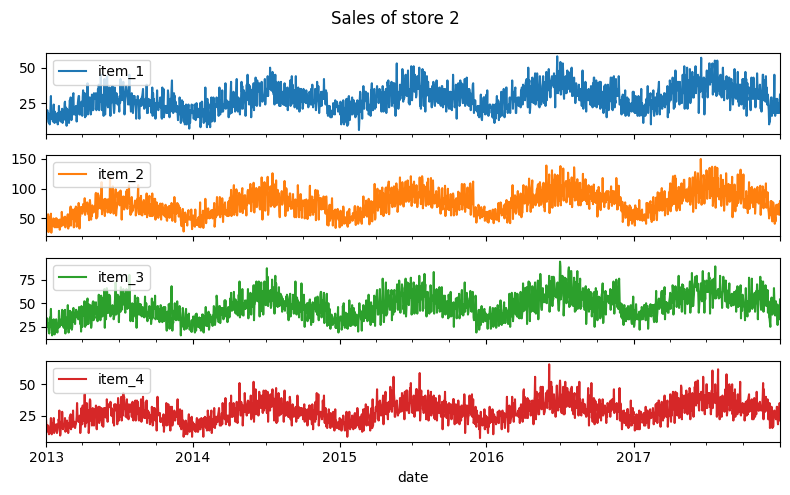

In [31]:
# Plot a subset of the time series
fig, ax = plt.subplots(figsize=(8, 5))
data.iloc[:, :4].plot(
    legend=True,
    subplots=True,
    sharex=True,
    title="Sales of store 2",
    ax=ax,
)
fig.tight_layout()

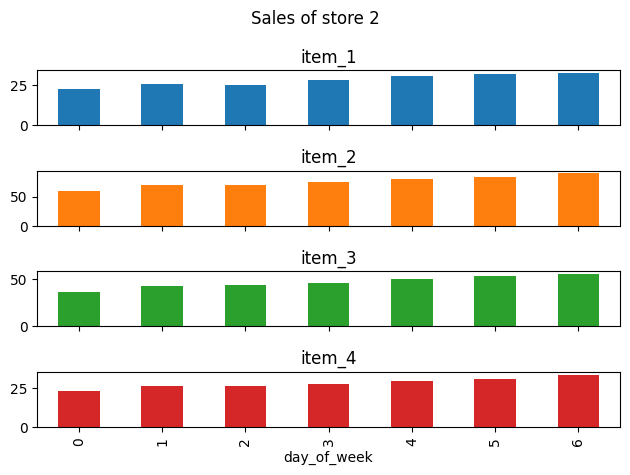

In [32]:
# Quick and dirty plot to check for weekly seasonality
(
    data.assign(day_of_week=lambda x: data.index.weekday).groupby("day_of_week").mean()
).iloc[:, :4].plot(
    legend=False,
    subplots=True,
    sharex=True,
    title="Sales of store 2",
    kind="bar",
)
plt.tight_layout()

Let's add the day of the week to use as an exogenous feature.

In [33]:
data["day_of_week"] = data.index.weekday

# Linear models would better capture seasonality using fourier or cyclical features.
# Read more about them here:
# https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.transformations.series.fourier.FourierFeatures.html
# https://feature-engine.trainindata.com/en/latest/user_guide/creation/CyclicalFeatures.html#cyclical-features

In [34]:
data

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,...,item_42,item_43,item_44,item_45,item_46,item_47,item_48,item_49,item_50,day_of_week
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,12.0,41.0,19.0,21.0,4.0,34.0,39.0,49.0,28.0,51.0,...,25.0,36.0,12.0,45.0,43.0,12.0,45.0,29.0,43.0,1
2013-01-02,16.0,33.0,32.0,14.0,6.0,40.0,47.0,42.0,21.0,56.0,...,21.0,35.0,25.0,50.0,52.0,13.0,37.0,25.0,57.0,2
2013-01-03,16.0,46.0,26.0,12.0,12.0,41.0,43.0,46.0,29.0,46.0,...,20.0,52.0,18.0,56.0,30.0,5.0,45.0,30.0,45.0,3
2013-01-04,20.0,50.0,34.0,17.0,16.0,41.0,44.0,55.0,32.0,56.0,...,28.0,50.0,24.0,57.0,46.0,19.0,32.0,20.0,45.0,4
2013-01-05,16.0,44.0,25.0,14.0,9.0,47.0,55.0,64.0,45.0,53.0,...,39.0,41.0,19.0,78.0,41.0,18.0,53.0,20.0,55.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-27,19.0,74.0,36.0,26.0,20.0,56.0,65.0,79.0,51.0,63.0,...,33.0,45.0,31.0,99.0,59.0,22.0,48.0,30.0,79.0,2
2017-12-28,21.0,69.0,40.0,23.0,18.0,63.0,73.0,91.0,60.0,78.0,...,46.0,64.0,31.0,99.0,64.0,24.0,37.0,31.0,68.0,3
2017-12-29,18.0,56.0,33.0,21.0,25.0,72.0,69.0,99.0,48.0,76.0,...,56.0,59.0,37.0,91.0,78.0,33.0,56.0,33.0,67.0,4


# Local forecasting approach: Training one model per time series

A different model is trained for each item of the store.

In [35]:
# Preprocessing and features
from sklearn.preprocessing import StandardScaler

# Traditional machine learning models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# Forecasters from skforecast
from skforecast.recursive import ForecasterRecursive
from skforecast.recursive import ForecasterRecursiveMultiSeries
from skforecast.preprocessing import RollingFeatures

In [36]:
rolling = RollingFeatures(
    stats = ['mean', 'std', 'mean', 'std'],
    window_sizes = [7, 7, 30, 30]
)

In [37]:
# Create forecaster
forecaster = ForecasterRecursive(
    regressor=Ridge(alpha=1),
    lags=7,
    window_features=rolling,
)

In [38]:
# Check the feature matrix and target variable
# created by the `forecaster` object.
time_series_1 = data["item_1"]
X_train, y_train = forecaster.create_train_X_y(y=time_series_1)
display(X_train.head(), y_train.head())

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30
date,,,,,,,,,,,
2013-01-31,10.0,18.0,15.0,12.0,14.0,17.0,14.0,14.285714,2.751623,15.666667,4.349660
2013-02-01,16.0,10.0,18.0,15.0,12.0,14.0,17.0,14.571429,2.819997,15.800000,4.294343
2013-02-02,16.0,16.0,10.0,18.0,15.0,12.0,14.0,14.428571,2.699206,15.800000,4.294343
2013-02-03,23.0,16.0,16.0,10.0,18.0,15.0,12.0,15.714286,4.191829,16.033333,4.491243
2013-02-04,14.0,23.0,16.0,16.0,10.0,18.0,15.0,16.000000,3.958114,15.833333,4.441834


date
2013-01-31    16.0
2013-02-01    16.0
2013-02-02    23.0
2013-02-03    14.0
2013-02-04    18.0
Freq: D, Name: y, dtype: float64

In [39]:
# Target time series column names
target_cols = data.filter(like="item_").columns

# Exogenous feature column names
exog_cols = ["day_of_week"]

# Forecast horizon: Number of steps to predict
steps = 14

In [40]:
freq = data.index.freq.name
future_start_date = data.index.max() + pd.Timedelta(f"1{freq}")
future_dates = pd.date_range(start=future_start_date, freq=freq, periods=steps)

In [41]:
# Prepare exogenous features for the future
freq = data.index.freq.name
future_start_date = data.index.max() + pd.Timedelta(f"1{freq}")
future_dates = pd.date_range(start=future_start_date, freq=freq, periods=steps)

future_exog = pd.DataFrame(index=future_dates)
future_exog["day_of_week"] = future_exog.index.weekday

In [42]:
# Prepare containers to store predictions
models = {}
predictions = {}

# Train a model and make a forecast for each time series
for item in target_cols:

    # Create forecaster
    forecaster = ForecasterAutoregCustom(
        regressor=Ridge(alpha=1),
        fun_predictors=create_predictors,
        name_predictors=name_predictors,
        window_size=30,  # Largest window size needed
        # by `create_predictors`
        transformer_y=StandardScaler(),
        transformer_exog=StandardScaler(),
    )

    # Fit model
    forecaster.fit(y=data[item], exog=data[exog_cols])

    y_pred = forecaster.predict(steps=14, exog=future_exog)

    models[item] = forecaster
    predictions[item] = y_pred

# Results
forecast = pd.DataFrame(predictions)
forecast

NameError: name 'ForecasterAutoregCustom' is not defined

In [ ]:
# Plot forecast

# Select a random subsample of timeseries
num_timeseries = 5
data_subset = data[target_cols].sample(n=num_timeseries, axis=1, random_state=123)

# Plotting
fig, axs = plt.subplots(nrows=num_timeseries, figsize=[10, 3 * num_timeseries])
for ix in range(num_timeseries):
    item = data_subset.columns[ix]
    ax = axs[ix]

    data_subset.iloc[-30:][item].plot(ax=ax, label="actuals")
    forecast.loc[:, item].plot(ax=ax, linestyle="--", label="forecast")
    ax.legend()
    ax.set_title(f"{item}")

plt.tight_layout()

In [ ]:
models["item_1"].get_feature_importances()

## Global forecasting approach: Training one model for all time series

In [ ]:
# Preprocessing and features
from sklearn.preprocessing import StandardScaler

# Traditional machine learning models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# Forecasters from skforecast (recursive)
from skforecast.ForecasterAutoregMultiSeries import ForecasterAutoregMultiSeries
from skforecast.ForecasterAutoregMultiSeriesCustom import (
    ForecasterAutoregMultiSeriesCustom,
)

In [ ]:
# Define a function to extract lag and window features
# See: https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/custom-predictors.html
def create_predictors(y):
    """
    Create first 7 lags of a time series.
    Calculate rolling mean and standard deviation with window 7 and 30.
    """

    lags = y[-1:-8:-1]  # window_size = 8
    mean_7 = np.mean(y[-7:])  # window_size = 7
    std_7 = np.std(y[-7:])
    mean_30 = np.mean(y[-30:])  # window_size = 30
    std_30 = np.std(y[-30:])

    predictors = np.hstack([lags, mean_7, std_7, mean_30, std_30])

    return predictors


name_predictors = [f"lag_{i}" for i in range(1, 8)] + [
    "mean_7",
    "std_7",
    "mean_30",
    "std_30",
]
name_predictors

In [ ]:
# Create and fit a forecaster

# Create forecaster
forecaster = ForecasterAutoregMultiSeriesCustom(
    regressor=Ridge(alpha=1),
    fun_predictors=create_predictors,
    name_predictors=name_predictors,
    window_size=30,  # Largest window size needed
    # by `create_predictors`
    transformer_series=StandardScaler(),
    transformer_exog=StandardScaler(),
)

# REFERENCE: To create forecaster with only lag features and no window features
# forecaster = ForecasterAutoregMultiSeries(
#                  regressor        = Ridge(alpha=1),
#                  lags             = 7
#                  transformer_series    = StandardScaler(),
#                  transformer_exog = StandardScaler(),
#              )

# Target time series column names
target_cols = data.filter(like="item_").columns

# Exogenous feature column names
exog_cols = ["day_of_week"]

forecaster.fit(
    series=data[target_cols],  # Dataframe of target time series at train time
    exog=data[exog_cols],  # Dataframe of exogenous variables at train time
)

forecaster

In [ ]:
data.head()

In [ ]:
X_train, y_train, y_index, y_train_index = forecaster.create_train_X_y(
    series=data[target_cols], exog=data[exog_cols]
)
display(X_train.columns)
display(X_train.head(), y_train.head())

In [ ]:
# Forecast horizon: Number of steps to predict
steps = 14

# Prepare exogenous features for the future
freq = data.index.freq.name
future_start_date = data.index.max() + pd.Timedelta(f"1{freq}")
future_dates = pd.date_range(start=future_start_date, freq=freq, periods=steps + 1)

future_exog = pd.DataFrame(index=future_dates)
future_exog["day_of_week"] = future_exog.index.weekday

In [ ]:
# Predict

# Forecast for item_1 and item_2
forecast_item_1_2 = forecaster.predict(
    steps=steps, exog=future_exog, levels=["item_1", "item_2"]
)
forecast_item_1_2

In [ ]:
# Forecast for all items
forecast = forecaster.predict(steps=steps, exog=future_exog, levels=None)
forecast

In [ ]:
# Plot forecast

# Select a random subsample of timeseries
num_timeseries = 5
data_subset = data.sample(n=num_timeseries, axis=1, random_state=123)

# Plotting
fig, axs = plt.subplots(nrows=num_timeseries, figsize=[10, 3 * num_timeseries])
for ix in range(num_timeseries):
    item = data_subset.columns[ix]
    ax = axs[ix]

    data_subset.iloc[-30:][item].plot(ax=ax, label="actuals")
    forecast.loc[:, item].plot(ax=ax, linestyle="--", label="forecast")
    ax.legend()
    ax.set_title(f"{item}")

plt.tight_layout()

In [ ]:
# Interval forecasts for item_1 and item_2
# See more details here: https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/probabilistic-forecasting.html

forecast_intervals = forecaster.predict_interval(
    steps=steps, exog=future_exog, levels=["item_1", "item_2"]
)
forecast_intervals.head(3)

## Feature importance

In [ ]:
# Feature importance
forecaster.get_feature_importances()

In [ ]:
# Plot feature importance
(
    forecaster.get_feature_importances()
    .assign(importance=lambda df: np.abs(df.importance))
    .nlargest(n=10, columns=["importance"])
    .set_index("feature")
).plot(kind="bar")

In [ ]:
model = Ridge(alpha=1)

In [ ]:
model.fit()

## Weights in multi-series

The weights are used to control the influence that each observation has on the training of the model. `ForecasterAutoregMultiseries` accepts two types of weights:

+ `series_weights` controls the relative importance of each series. If a series has twice as much weight as the others, the observations of that series influence the training twice as much. The higher the weight of a series relative to the others, the more the model will focus on trying to learn that series.

+ `weight_func` controls the relative importance of each observation according to its index value. For example, a function that assigns a lower weight to certain dates.

If the two types of weights are indicated, they are **multiplied to create the final weights**. The resulting `sample_weight` cannot have negative values.

<p style="text-align: center">
<img src="./images/forecaster_multi_series_sample_weight.png" style="width: 900px">
<br>
<font size="2.5"> <i>Weights in multi-series.</i></font>
</p>

+ `series_weights` is a dict of the form `{'series_column_name': float}`. If a series is used during `fit` and is not present in `series_weights`, it will have a weight of 1.

+ `weight_func` is a function that defines the individual weights of each sample **based on the index**. 
  
    + If it is a `callable`, the same function will apply to all series. 
  
    + If it is a `dict` of the form `{'series_column_name': callable}`, a different function can be used for each series. A weight of 1 is given to all series not present in `weight_func`.

In [ ]:
# Weights in Multi-Series


def custom_weights(index):
    """
    Return 0 if index is between '2013-01-01' and '2013-01-31', 1 otherwise.
    """
    weights = np.where((index >= "2013-01-01") & (index <= "2013-01-31"), 0, 1)

    return weights


forecaster = ForecasterAutoregMultiSeries(
    regressor=Ridge(random_state=123),
    lags=24,
    transformer_series=StandardScaler(),
    transformer_exog=StandardScaler(),
    weight_func=custom_weights,
    series_weights={
        "item_1": 1.0,
        "item_2": 2.0,
        "item_3": 1.0,
    },  # Same as {'item_2': 2.}
)

forecaster.fit(series=data)
forecaster.predict(steps=24).head(3)

<script src="https://kit.fontawesome.com/d20edc211b.js" crossorigin="anonymous"></script>

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px;">
<p class="title">
    <i class="fa-triangle-exclamation fa" style="font-size: 18px; color:#ff9100;"></i>
    <b style="color: #ff9100;"> &nbsp Warning</b>
</p>

The <code>weight_func</code> and <code>series_weights</code> arguments will be ignored if the regressor does not accept <code>sample_weight</code> in its <code>fit</code> method.

</div>

The source code of the `weight_func` added to the forecaster is stored in the argument `source_code_weight_func`. If `weight_func` is a `dict`, it will be a `dict` of the form `{'series_column_name': source_code_weight_func}` .